# Localization Analysis — Unitree go2

**Course:** Ciência de Dados — FEI Mestrado  
**Description:** Analysis of RTABMAP localization quality using one or two cameras in a go2 robot.

---

### Data Sources
| File | Description |
|------|-------------|
| `localization_log.csv` | Per-update metrics from `/rtabmap/info` and `/localization_pose` (inliers, covariance, pose, etc.) |
| `plan_log.csv` | Planned path poses from `/plan` topic, grouped by `plan_id` |

### Sections
1. **Data Loading** — read CSV logs from a given run folder  
2. **Path Visualization** — planned path vs actual robot trajectory  
3. **Localization Quality** — inliers, hypothesis ratio, covariance over time


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the .csv logs from localization and planning navigation
loc  = pd.read_csv('localization_analysis/data/logs/logger_csv_1/localization_log.csv')
plan = pd.read_csv('localization_analysis/data/logs/logger_csv_1/plan_log.csv')

In [ ]:
# Take the first path that NAV2 stack calculated (the plan_id = 1)
last_plan = plan[plan['plan_id'] == plan['plan_id'].min()]
last_plan

,plan_id,pose_index,x,y
0,1,0,-2.7519,2.1549
1,1,1,-2.7019,2.1049
2,1,2,-2.6519,2.0549
3,1,3,-2.6019,2.0049
4,1,4,-2.5519,1.9549
...,...,...,...,...
159,1,159,1.7122,2.1049
160,1,160,1.7187,2.1549
161,1,161,1.7270,2.2049
162,1,162,1.7371,2.2549


In [ ]:
# Drop rows where pose was not yet received (NaN)
actual = loc.dropna(subset=['pos_x', 'pos_y'])
actual

,timestamp_sec,camera_mode,node_id,inliers,matches,inlier_ratio,hypothesis_ratio,loop_closure_id,wm_size,detection_time_ms,total_time_ms,pos_x,pos_y,yaw,cov_xx,cov_yy,cov_yaw,cov_pos_trace
0,1.774646e+09,single,19532,4,35,0.0090,1.0,0,977,200.94,212.78,-3.0953,2.4795,2.3537,9999.000000,9999.000000,9999.000000,19998.000000
1,1.774646e+09,single,19533,3,31,0.0068,1.0,0,977,179.96,191.82,-3.0952,2.4796,2.3536,9999.000000,9999.000000,9999.000000,19998.000000
2,1.774646e+09,single,19534,0,0,0.0000,0.0,0,977,180.05,190.29,-3.1194,2.4870,2.3501,9999.000000,9999.000000,9999.000000,19998.000000
3,1.774646e+09,single,19535,0,0,0.0000,0.0,0,977,156.80,161.43,-3.1141,2.4825,2.3498,9999.000000,9999.000000,9999.000000,19998.000000
4,1.774646e+09,single,19536,0,0,0.0000,0.0,0,977,154.73,161.19,-3.1174,2.4805,2.3486,9999.000000,9999.000000,9999.000000,19998.000000
5,1.774646e+09,single,19537,3,22,0.0073,1.0,0,977,208.54,226.50,-2.9903,2.3139,2.4410,9999.000000,9999.000000,9999.000000,19998.000000
6,1.774646e+09,single,19538,0,0,0.0000,0.0,0,977,228.65,237.78,-2.7998,2.1400,2.4517,9999.000000,9999.000000,9999.000000,19998.000000
7,1.774646e+09,single,19539,3,23,0.0066,1.0,0,977,251.72,261.95,-2.7540,2.1281,2.4599,9999.000000,9999.000000,9999.000000,19998.000000
8,1.774646e+09,single,19540,3,34,0.0064,1.0,0,977,193.76,200.83,-2.7563,2.1308,2.4618,9999.000000,9999.000000,9999.000000,19998.000000
9,1.774646e+09,single,19541,0,0,0.0000,0.0,0,977,243.48,252.27,-2.7583,2.1327,2.4630,9999.000000,9999.000000,9999.000000,19998.000000


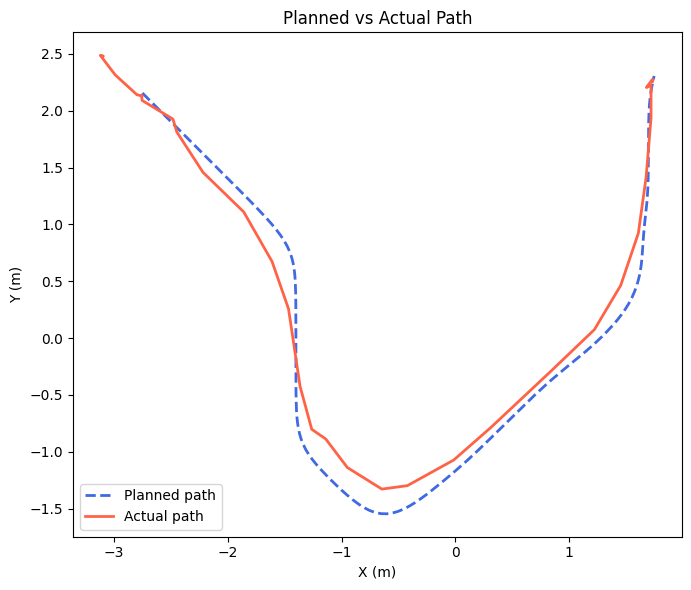

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

# Planned path — dashed royalblue (the intention)
ax.plot(last_plan['x'], last_plan['y'],
        color='royalblue', linestyle='--', linewidth=2, label='Planned path')

# Actual path — solid tomato (the execution)
ax.plot(actual['pos_x'], actual['pos_y'],
        color='tomato', linestyle='-', linewidth=2, label='Actual path')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('Planned vs Actual Path')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()